# Aufgabe4.1


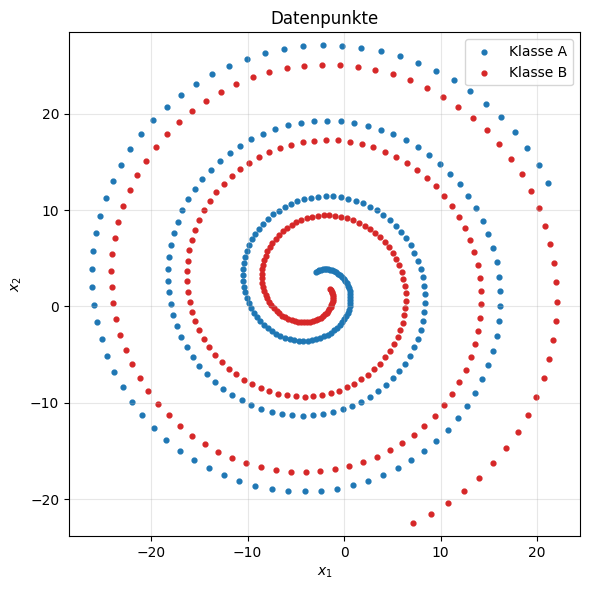

In [36]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# 1. Create the dataset
u = np.arange(1, 251)                      # u = 1, ..., 250

# Class A
xa1 = -3 + 0.1 * np.sin(0.08 * u) * (u + 15)
xa2 =  2 + 0.1 * np.cos(0.08 * u) * (u + 15)
# Class B (same spiral, phase-shifted by 1.6 rad)
xb1 = -3 + 0.1 * np.sin(0.08 * u + 1.6) * (u + 15)
xb2 =  2 + 0.1 * np.cos(0.08 * u + 1.6) * (u + 15)

XA = np.stack([xa1, xa2], axis=1)
XB = np.stack([xb1, xb2], axis=1)

X = np.vstack([XA, XB]).astype(np.float32)                 # (500, 2)
y = np.concatenate([np.zeros(250), np.ones(250)]).astype(np.float32)  # A=0, B=1

X_t = torch.from_numpy(X)
y_t = torch.from_numpy(y)


# 2. Plot the raw data
plt.figure(figsize=(6, 6))
plt.scatter(XA[:, 0], XA[:, 1], s=12, c="tab:blue", label="Klasse A")
plt.scatter(XB[:, 0], XB[:, 1], s=12, c="tab:red",  label="Klasse B")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("Datenpunkte"); plt.legend(); plt.axis("equal"); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig("data.png", dpi=130); plt.show()


In [37]:
#3. RBF network
class RBFNet(nn.Module):
    """One hidden layer of Gaussian RBF units + linear output (1 logit)."""

    def __init__(self, n_centers=75, in_dim=2, init_centers=None, init_sigma=2.0):
        super().__init__()
        if init_centers is None:
            init_centers = torch.randn(n_centers, in_dim)
        self.centers = nn.Parameter(init_centers.clone())          # (C, D)
        # learn log(sigma) so sigma stays positive
        self.log_sigma = nn.Parameter(torch.full((n_centers,), np.log(init_sigma)))
        self.out = nn.Linear(n_centers, 1)                         # output weights

    def rbf(self, x):
        # squared distance from every point to every center -> (N, C)
        diff = x.unsqueeze(1) - self.centers.unsqueeze(0)          # (N, C, D)
        dist2 = (diff ** 2).sum(-1)                                # (N, C)
        sigma = torch.exp(self.log_sigma)                          # (C,)
        return torch.exp(-dist2 / (2.0 * sigma ** 2))             # (N, C)

    def forward(self, x):
        return self.out(self.rbf(x)).squeeze(-1)                   # logits (N,)
    
    # initialize the 75 centers from random data points; much faster convergence
idx = np.random.choice(len(X), 75, replace=False)
model = RBFNet(75, init_centers=torch.from_numpy(X[idx]), init_sigma=2.0)

opt = torch.optim.Adam(model.parameters(), lr=0.05)
loss_fn = nn.BCEWithLogitsLoss()

for epoch in range(2000):
    opt.zero_grad()
    logits = model(X_t)
    loss = loss_fn(logits, y_t)
    loss.backward()
    opt.step()
    if (epoch + 1) % 400 == 0:
        with torch.no_grad():
            acc = ((logits > 0).float() == y_t).float().mean().item()
        print(f"epoch {epoch+1:4d}  loss {loss.item():.4f}  acc {acc:.3f}")

with torch.no_grad():
    final_acc = ((model(X_t) > 0).float() == y_t).float().mean().item()
print(f"final training accuracy: {final_acc:.3f}")


epoch  400  loss 0.0612  acc 0.998
epoch  800  loss 0.0219  acc 1.000
epoch 1200  loss 0.0116  acc 1.000
epoch 1600  loss 0.0076  acc 1.000
epoch 2000  loss 0.0049  acc 1.000
final training accuracy: 1.000


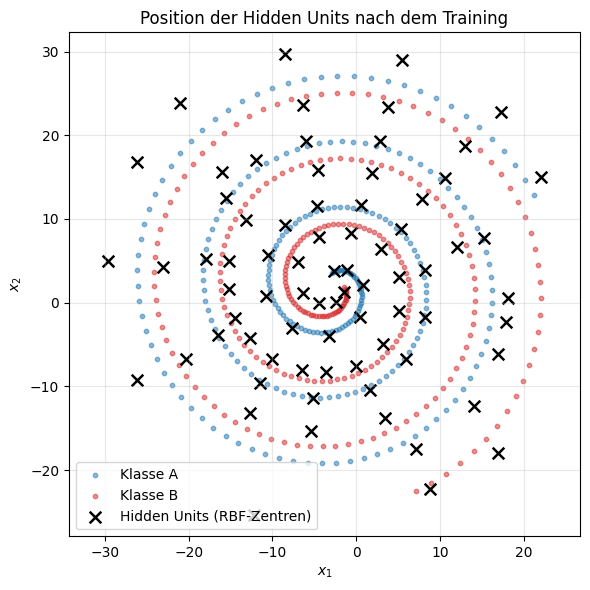

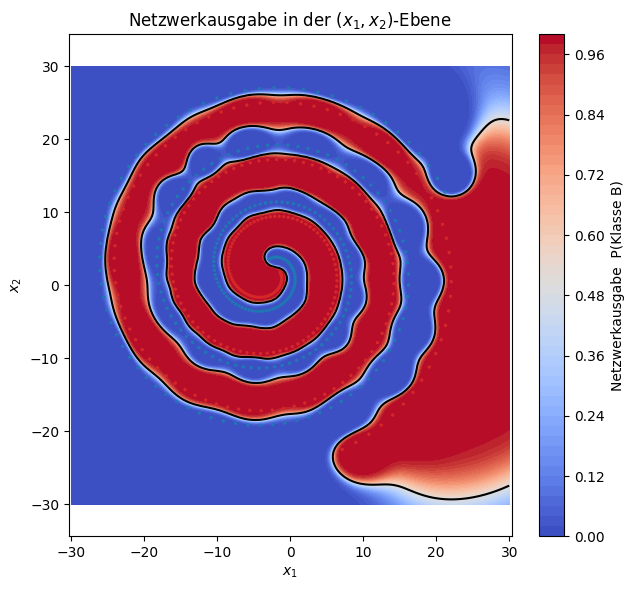

In [38]:
# 4. Plot learned hidden-unit (center) positions
centers = model.centers.detach().numpy()
plt.figure(figsize=(6, 6))
plt.scatter(XA[:, 0], XA[:, 1], s=10, c="tab:blue", alpha=.5, label="Klasse A")
plt.scatter(XB[:, 0], XB[:, 1], s=10, c="tab:red",  alpha=.5, label="Klasse B")
plt.scatter(centers[:, 0], centers[:, 1], s=70, marker="x",
            c="black", linewidths=1.8, label="Hidden Units (RBF-Zentren)")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("Position der Hidden Units nach dem Training")
plt.legend(); plt.axis("equal"); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig("centers.png", dpi=130); plt.show()


# 5. Plot network output over [-30, 30]^2, step 0.25
g = np.arange(-30, 30 + 1e-9, 0.25, dtype=np.float32)     # 241 points / dim
GX1, GX2 = np.meshgrid(g, g)
grid = np.stack([GX1.ravel(), GX2.ravel()], axis=1)

with torch.no_grad():
    out = torch.sigmoid(model(torch.from_numpy(grid))).numpy()
out = out.reshape(GX1.shape)

plt.figure(figsize=(6.5, 6))
plt.contourf(GX1, GX2, out, levels=50, cmap="coolwarm")
plt.colorbar(label="Netzwerkausgabe  P(Klasse B)")
plt.contour(GX1, GX2, out, levels=[0.5], colors="k", linewidths=1.5)  # decision boundary
plt.scatter(XA[:, 0], XA[:, 1], s=6, c="tab:blue", edgecolors="none")
plt.scatter(XB[:, 0], XB[:, 1], s=6, c="tab:red",  edgecolors="none")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("Netzwerkausgabe in der $(x_1, x_2)$-Ebene")
plt.axis("equal"); plt.tight_layout(); plt.savefig("output.png", dpi=130); plt.show()



# Aufgabe4.2 - CNN classifier for MNIST


['t10k-images.idx3-ubyte', 't10k-labels.idx1-ubyte', 'train-images.idx3-ubyte', 'train-labels.idx1-ubyte']
device: cuda
(10000, 28, 28)


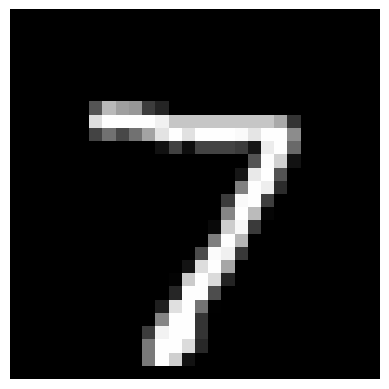

In [39]:
import zipfile, os
zip_path = r"C:\Users\xiyun\Downloads\mnist_dataset.zip" 
out_dir  = r"C:\Users\xiyun\Downloads\training"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(out_dir)
print(os.listdir(out_dir))

import os, gzip
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

path = r"C:\Users\xiyun\Downloads\training\t10k-images.idx3-ubyte"

def read_images(path):
    f = gzip.open(path, "rb") if path.endswith(".gz") else open(path, "rb")
    with f:
        assert int.from_bytes(f.read(4), "big") == 2051
        n, r, c = (int.from_bytes(f.read(4), "big") for _ in range(3))
        buf = f.read()
    return np.frombuffer(buf, np.uint8).reshape(n, r, c)

#loads the image file and shows the first picture
X = read_images(path)
print(X.shape)
plt.imshow(X[0], cmap="gray"); plt.axis("off"); plt.show()



In [40]:
#load all four files (adds the label reader)

def read_labels(path):
    f = gzip.open(path, "rb") if path.endswith(".gz") else open(path, "rb")
    with f:
        assert int.from_bytes(f.read(4), "big") == 2049     # label magic number
        n = int.from_bytes(f.read(4), "big")
        buf = f.read()
    return np.frombuffer(buf, np.uint8)

p = lambda name: os.path.join(out_dir, name)
Xtr = read_images(p("train-images.idx3-ubyte"))
ytr = read_labels(p("train-labels.idx1-ubyte"))
Xte = read_images(p("t10k-images.idx3-ubyte"))
yte = read_labels(p("t10k-labels.idx1-ubyte"))
print("train", Xtr.shape, " test", Xte.shape)

train (60000, 28, 28)  test (10000, 28, 28)


In [41]:
#preprocess into tensors and batches
MEAN, STD = 0.1307, 0.3081                       # standard MNIST mean/std
def to_tensor(X):
    t = torch.from_numpy(X.astype(np.float32) / 255.0).unsqueeze(1)   # (N,1,28,28)
    return (t - MEAN) / STD

Xtr_t, Xte_t = to_tensor(Xtr), to_tensor(Xte)
ytr_t = torch.from_numpy(ytr.astype(np.int64))
yte_t = torch.from_numpy(yte.astype(np.int64))

train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=128, shuffle=True)
test_loader  = DataLoader(TensorDataset(Xte_t, yte_t), batch_size=512)

In [42]:
# CNN (conv blocks + fully-connected layers near the output)
class CNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(     # input (N, 1, 28, 28)
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 28 -> 14 input channel = 1, output channels = 32, coverlution kernel size = 3
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 14 -> 7 input channel = 32, output channels = 64, coverlution kernel size = 3
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(128, n_classes),                                    # 10 logits
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = CNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

In [43]:
#train and record the error each epoch
@torch.no_grad()
def evaluate(loader):
    model.eval()
    correct = total = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        correct += (model(xb).argmax(1) == yb).sum().item()
        total += yb.size(0)
    return correct / total

EPOCHS = 5
hist = {"train_err": [], "test_err": []}
for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward(); opt.step()
        running += loss.item() * xb.size(0)
    tr_err = 1 - evaluate(train_loader)      # error = 1 - accuracy
    te_err = 1 - evaluate(test_loader)
    hist["train_err"].append(tr_err)
    hist["test_err"].append(te_err)
    print(f"epoch {epoch}  loss {running/len(train_loader.dataset):.4f}"
          f"  train_err {tr_err:.4f}  test_err {te_err:.4f}")

epoch 1  loss 0.1957  train_err 0.0155  test_err 0.0173
epoch 2  loss 0.0612  train_err 0.0097  test_err 0.0113
epoch 3  loss 0.0421  train_err 0.0066  test_err 0.0111
epoch 4  loss 0.0342  train_err 0.0047  test_err 0.0094
epoch 5  loss 0.0266  train_err 0.0040  test_err 0.0095


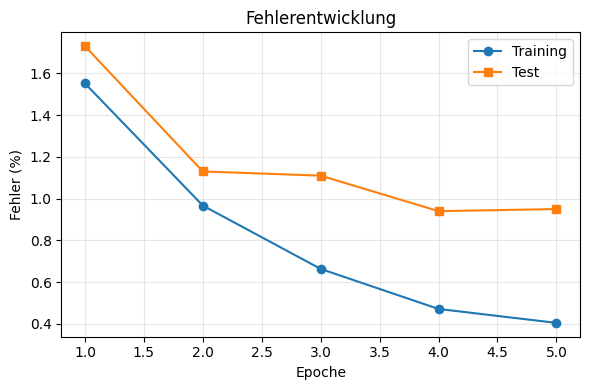

In [44]:
#plot the error development
ep = range(1, EPOCHS + 1)
plt.figure(figsize=(6, 4))
plt.plot(ep, [e*100 for e in hist["train_err"]], "o-", label="Training")
plt.plot(ep, [e*100 for e in hist["test_err"]], "s-", label="Test")
plt.xlabel("Epoche"); plt.ylabel("Fehler (%)"); plt.title("Fehlerentwicklung")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

total misclassified: 95


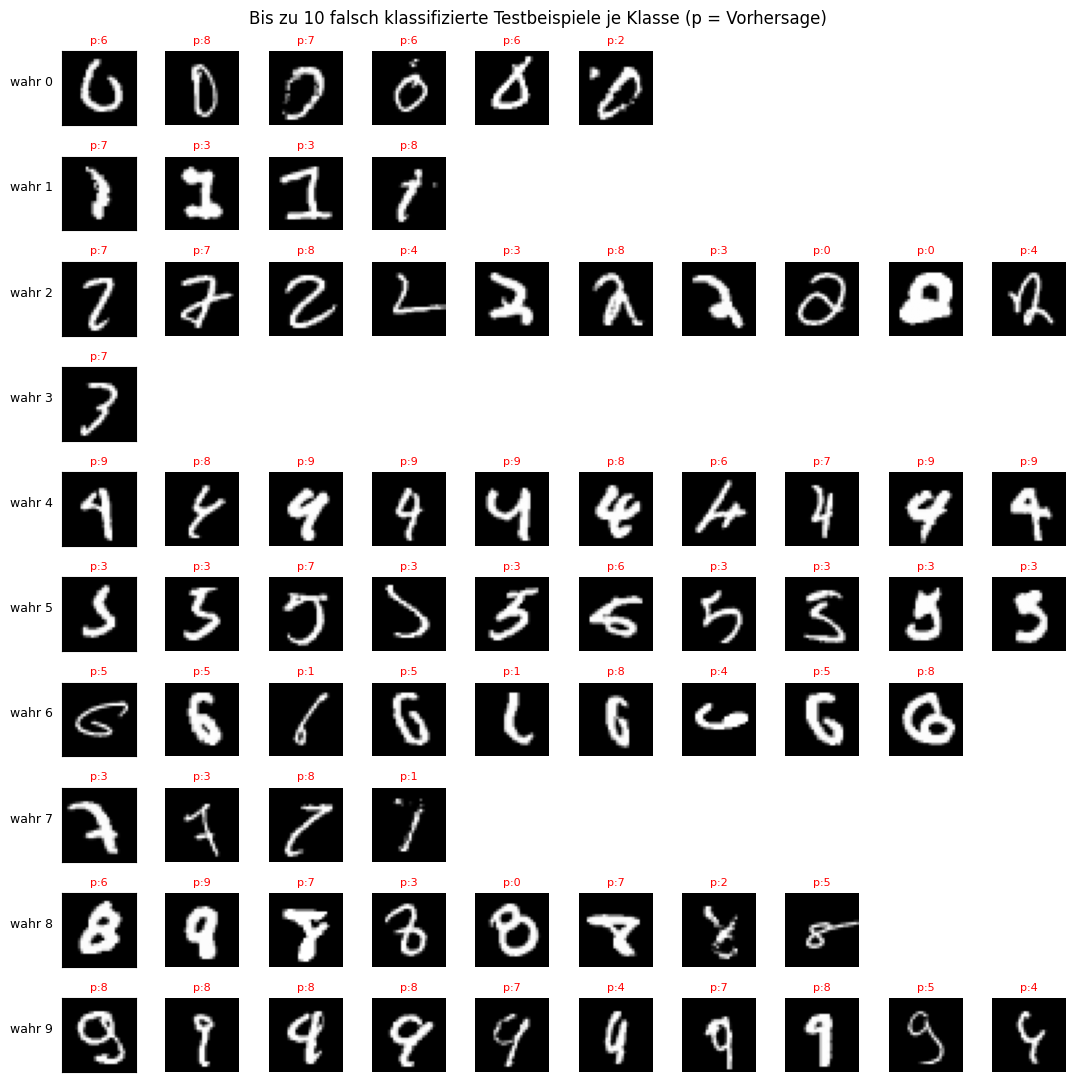

In [45]:
#up to 10 mislassified test samples per class
model.eval()
with torch.no_grad():
    all_preds = []
    for xb, _ in test_loader:
        all_preds.append(model(xb.to(device)).argmax(1).cpu().numpy())
all_preds = np.concatenate(all_preds)

wrong = np.where(all_preds != yte)[0]          # indices of misclassified test images
print("total misclassified:", len(wrong))

fig, axes = plt.subplots(10, 10, figsize=(11, 11))
for cls in range(10):
    idx = [i for i in wrong if yte[i] == cls][:10]   # wrong ones whose TRUE class is cls
    for k in range(10):
        ax = axes[cls, k]; ax.axis("off")
        if k < len(idx):
            i = idx[k]
            ax.imshow(Xte[i], cmap="gray")
            ax.set_title(f"p:{all_preds[i]}", fontsize=8, color="red")  # predicted label
    axes[cls, 0].set_ylabel(f"wahr {cls}", rotation=0, labelpad=22, fontsize=9)
    axes[cls, 0].axis("on"); axes[cls, 0].set_xticks([]); axes[cls, 0].set_yticks([])
plt.suptitle("Bis zu 10 falsch klassifizierte Testbeispiele je Klasse (p = Vorhersage)")
plt.tight_layout(); plt.show()